In [1]:
# ==========================
# STEP 1: IMPORTING LIBRARIES
# ==========================
# Essential libraries for data handling, visualization, model training, and evaluation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ==========================
# STEP 2: LOADING THE DATASET
# ==========================
df= pd.read_excel(r"C:\Users\Dattaprasad\Downloads\home loan data_Hdfc_bank.xlsx")

In [3]:
df

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Property_Location,Existing_Loans,Approval_Status,Aadhaar_Number,PAN_Number,CIBIL_Score,Education_Details
0,APP1000,59,Male,Single,2,Graduate,Salaried,139982,1125,2444351,120,463,Semi-Urban,Yes,Rejected,1191100999,CVBKB4057R,874,High School
1,APP1001,49,Female,Single,3+,Graduate,Self-Employed,83619,1529,226060,48,742,Rural,No,Rejected,837903768748,MODAW8438B,783,High School
2,APP1002,35,Female,Single,2,Not Graduate,Salaried,61479,26170,1336530,120,618,Rural,No,Approved,595120542985,KELIL8337T,464,Diploma
3,APP1003,63,Male,Single,2,Not Graduate,Salaried,96437,8438,1874329,12,888,Rural,No,Approved,230878157807,BDPVH8258D,682,PhD
4,APP1004,28,Female,Single,2,Not Graduate,Salaried,113540,20095,230544,36,803,Rural,No,Approved,325637559194,LUUTI9330Y,508,Master's
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,APP1495,46,Male,Single,3+,Not Graduate,Self-Employed,130357,21300,1431420,24,525,Semi-Urban,No,Approved,108184566925,FMTTA1337D,535,PhD
496,APP1496,30,Female,Married,3+,Graduate,Self-Employed,134052,5498,1930791,24,388,Semi-Urban,No,Rejected,484177156830,TUTCW5167C,605,Diploma
497,APP1497,46,Female,Single,2,Graduate,Self-Employed,71481,10582,2290482,120,829,Rural,No,Approved,250268480844,ACGMH2607Z,777,High School
498,APP1498,54,Male,Single,1,Not Graduate,Self-Employed,16283,46633,325391,180,670,Semi-Urban,Yes,Approved,18433779080,JTTXW6809R,319,Bachelor's


In [4]:
# ==========================
# STEP 3: DATA CLEANING & PREPROCESSING
# ==========================
# Removing unnecessary columns that do not contribute to the prediction
df.drop(columns=['Applicant_ID', 'Aadhaar_Number', 'PAN_Number','Approval_Status' ], inplace=True)

# Converting categorical values to numerical format
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)

# Encoding categorical variables into dummy/one-hot encoding
categorical_cols = ['Gender', 'Marital_Status', 'Education', 'Employment_Type', 'Property_Location', 'Existing_Loans', 'Education_Details']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Handling missing values using the most frequent strategy
imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [2]:
df.info()

NameError: name 'df' is not defined

In [6]:
# ==========================
# STEP 4: DEFINING FEATURES & TARGET VARIABLE
# ==========================
X = df
y = pd.read_excel('home loan data_Hdfc_bank.xlsx')['Approval_Status'].map({'Approved': 1, 'Rejected': 0})

In [7]:
# ==========================
# STEP 5: HANDLING DATA IMBALANCE USING SMOTE
# ==========================
# Since loan approval datasets are often imbalanced, we use SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [8]:
# ==========================
# STEP 6: SPLITTING THE DATA INTO TRAINING & TESTING SETS
# ==========================
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

In [9]:
# ==========================
# STEP 7: MODEL SELECTION & HYPERPARAMETER TUNING
# ==========================
# Defining the hyperparameter grid for GridSearchCV
param_grid = {
    'n_estimators': [500, 700, 900],
    'max_depth': [20, 30, 40],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

# Performing Grid Search with cross-validation to find the best model
grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Extracting the best parameters from Grid Search
best_params = grid_search.best_params_

Fitting 3 folds for each of 81 candidates, totalling 243 fits


In [10]:
# ==========================
# STEP 8: TRAINING THE OPTIMIZED RANDOM FOREST MODEL
# ==========================
best_model = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42)
best_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=4, n_estimators=700, random_state=42)

In [11]:
# ==========================
# STEP 9: MAKING PREDICTIONS
# ==========================
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [12]:
# ==========================
# STEP 10: MODEL EVALUATION
# ==========================
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

# Printing evaluation metrics
print(f'Best Parameters: {best_params}')
print(f'Accuracy: {accuracy:.4f}')
print(f'F1-score: {f1:.4f}')
print('Classification Report:', report)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 700}
Accuracy: 0.8356
F1-score: 0.8331
Classification Report:               precision    recall  f1-score   support

           0       0.95      0.71      0.81        73
           1       0.77      0.96      0.85        73

    accuracy                           0.84       146
   macro avg       0.86      0.84      0.83       146
weighted avg       0.86      0.84      0.83       146



<Figure size 600x400 with 0 Axes>

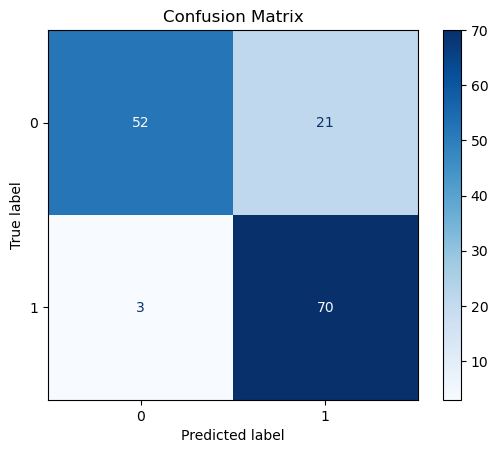

In [13]:
# ==========================
# STEP 11: CONFUSION MATRIX VISUALIZATION
# ==========================
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues', values_format='d')
disp.ax_.set_title('Confusion Matrix')
plt.grid(False)
plt.show()9

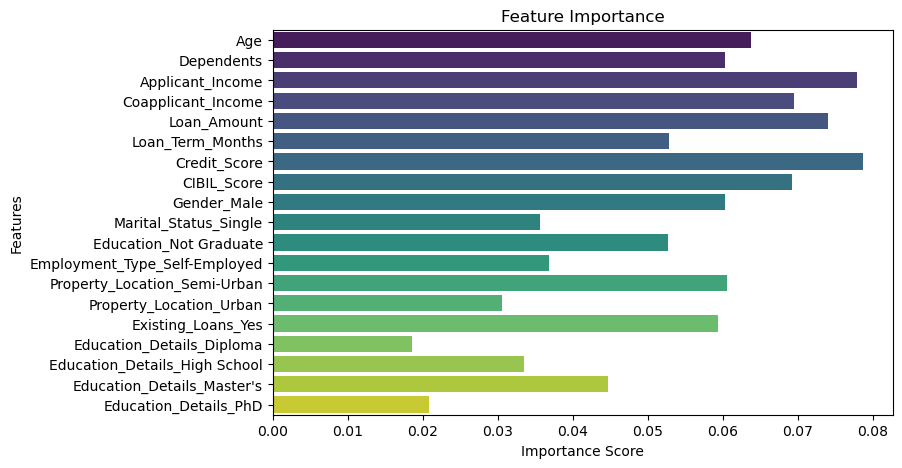

In [14]:
# ==========================
# STEP 12: FEATURE IMPORTANCE VISUALIZATION
# ==========================
importances = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

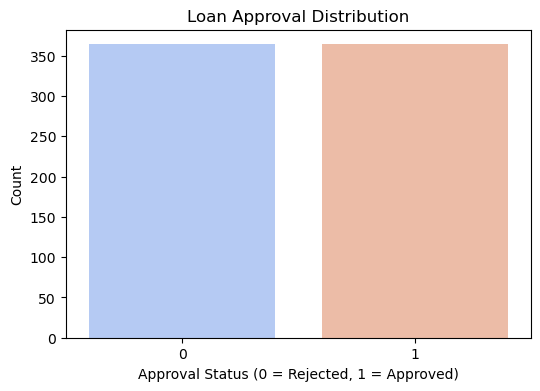

In [15]:
# ==========================
# STEP 13: LOAN APPROVAL DISTRIBUTION
# ==========================
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, palette='coolwarm')
plt.title('Loan Approval Distribution')
plt.xlabel('Approval Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Count')
plt.show()

In [16]:
# ==========================
# STEP 14: FINAL PREDICTIONS ON FULL DATASET
# ==========================
df['Predicted_Approval'] = best_model.predict(X)
df['Predicted_Approval'] = df['Predicted_Approval'].map({1: 'Approved', 0: 'Rejected'})

# Displaying the first 20 predictions
df[['Predicted_Approval']].head(100)

,Predicted_Approval
0,Rejected
1,Rejected
2,Rejected
3,Approved
4,Approved
...,...
95,Approved
96,Approved
97,Approved
98,Approved
